# Iteración de Valores

En este ejercicio vamos a implementar el primer método para solucionar Procesos de Decisión de Markov (MDPs). El método a implementar es la iteración de valores.

La iteración de valores esta basada en la fórmula:

![value_iteration](./img/value_iteration.png)

Para resolver los MDPs crearemos un archivo `value_iteration.py` el cual utilizaremos para solucionar el ambiente de Gridworld.

**Task 1**
1.	Implemente la classe `ValueIteration` con cuatro atributos:
    - `mdp` que corresponde al MDP a resolver (e.g., Gridworld) 
    - `discount` que corresponde al factor de decuento a utilizar, `0.9` por defecto.
    - `iterations` que corresponde a el número de iteraciones a realizar.
    - `values` que corresponde a los valores calculados para los estados del MDP.

2. El comportamiento del agente (de iteración de valores) esta dado por los métodos:
    - `run_value_iteration` que no recibe ningún parámatetro y ejecuta el algoritmo de iteración de valores para la solución del MDP.
    - `get_value` recibe un estado y retorna el valor correspondiende para dicho estado.
    - `compute_qvalue_from_values` recibe un estado y una acción y calcula el q valor correspondiente.
    - `compute_action_from_values` que calcula la acción a tomar (como la acción con el mejor valor en `values`) para un estado dado
    - `get_action` retorna la acción a tomar dado un estado (directamente como la acción de la política, sin exploración)
    - `get_qvalue` retorna el q valor dado un estado y una acción
    - `get_policy` que retorna la acción a tomar para un estado (como `get_action`). Si el estado no tiene una acción asociada a él, retorne `None`

# Entrega

Para esta tarea debe entregar: 
- La implementación de la iteración de valores para solucionar MDPs (`value_iteration.py`).
- Un documento de análisis respondiendo a las siguientes preguntas (con screenshots de la solución y las explicaciones correspondientes del comportamiento observado).
  -	Ejecute su implementación de iteración de valores para 5, 10, 15, 20, 30, 50 iteraciones, sobre el ambiente de gridworld. ¿Cuando convergen los valores o las acciones?
  -	Ejecute su implementación sobre el ambiente del puente (i.e., Bridge) durante 10 iteraciones. ¿Qué resultado observa si codifica el valor de descuento de 0.9 a 0.1. Explique si los resultados cambian y porqué. 
  
  Recuerde que el ambiente del puente se define con la matriz de `3x7` donde las filas 1 y 3 tienen recompensa -100 entre las columnas 2 y 6. La fila 2 corresponde a el puente, con entrada en la casilla `(2,1)` y salida en la casilla `(2,7)` con recompensa 100, como se muestra en la figura

  ![bridge](./img/bridge.png)


In [147]:
# Enviroment and MDP definition

import random

class EnvironmentNuevo:
    def __init__(self, board):
        self.board = board
        self.nrows = len(board)
        self.ncols = len(board[0]) 
        self.initial_state = self._find_initial_state()
        self.current_state = self.initial_state
        self.actions = ['up', 'right', 'down', 'left', 'exit']
        self.P = self._build_transition_matrix()
        
    def _build_transition_matrix(self):
        nA = len(self.actions)
    
        P = [[[[0 for _ in range(nA)] for _ in range(nA)]
              for _ in range(self.ncols)]
              for _ in range(self.nrows)]
    
        for i in range(self.nrows):
            for j in range(self.ncols):
            
                if self.board[i][j] == '#':
                    continue
                
                # Si es estado terminal
                if self._is_exit(i, j):
                    P[i][j][4][4] = 1.0  # exit → exit
                    continue
                
                for a in range(4):  # solo up,right,down,left
                
                    clockwise = (a + 1) % 4
                    counterclock = (a - 1) % 4
    
                    P[i][j][a][a] = 0.6
                    P[i][j][a][clockwise] = 0.2
                    P[i][j][a][counterclock] = 0.1
                    P[i][j][a][a] += 0.1  # 10% quedarse = misma acción
    
        return P


    def _find_initial_state(self):
        for i in range(self.nrows):
            for j in range(self.ncols):
                if self.board[i][j] == 'S':
                    return (i, j)
        return (1, 1)

    def get_current_state(self):
        return self.current_state

    def get_posible_actions(self, state):
        r, c = state
        if self._is_exit(r, c):
            return ['exit']
        if self.board[r][c] == '#':
            return []
        return ['up', 'right', 'down', 'left']

    def do_action(self, idx_action):
        r, c = self.current_state
    
        # Si es terminal
        if self._is_exit(r, c):
            if idx_action == 4:
                return float(self.board[r][c]), self.current_state
            return 0, self.current_state
    
        # Elegir acción real según probabilidades
        probs = self.P[r][c][idx_action]
        real_action_idx = random.choices(range(len(self.actions)), weights=probs, k=1)[0]
        real_action = self.actions[real_action_idx]
    
        nr, nc = self._move(r, c, real_action)
        self.current_state = (nr, nc)
    
        if self._is_exit(nr, nc):
            reward = float(self.board[nr][nc])
        else:
            reward = 0
    
        return reward, self.current_state



    def reset(self):
        self.current_state = self.initial_state

    def is_terminal(self):
        r, c = self.current_state
        return self._is_exit(r, c)

    def _is_exit(self, r, c):
        val = self.board[r][c]
        if isinstance(val, str):
            try:
                float(val)
                return True 
            except ValueError:
                return False
        return False

    def _move(self, r, c, action):
        dr, dc = 0, 0
        if action == 'up':
            dr = -1
        elif action == 'down':
            dr = 1
        elif action == 'left':
            dc = -1
        elif action == 'right':
            dc = 1

        nr, nc = r + dr, c + dc
        if nr < 0 or nr >= self.nrows or nc < 0 or nc >= self.ncols:
            return r, c
        if self.board[nr][nc] == '#':
            return r, c
        return nr, nc
   





# ------------- Value Iteration Algorithm for Gridworld -------------
class ValueIteration():
    def __init__(self, env, iterations, gamma=0.9):
        self.mdp = env
        self.discount = gamma
        self.iterations = iterations
        
        # valores como matriz 2D
        self.values = [[0 for _ in range(self.mdp.ncols)]
                       for _ in range(self.mdp.nrows)]

        # usar exactamente las acciones del entorno
        self.actions = self.mdp.actions
        self.action_to_idx = {a: i for i, a in enumerate(self.actions)}

    # -------------------------
    # Algoritmo principal
    # -------------------------

    def run_value_iteration(self):
        for _ in range(self.iterations):
            new_values = [row.copy() for row in self.values]

            for r in range(self.mdp.nrows):
                for c in range(self.mdp.ncols):

                    # ignorar paredes
                    if self.mdp.board[r][c] == '#':
                        continue

                    state = (r, c)
                    actions = self.mdp.get_posible_actions(state)

                    # estado terminal
                    if actions == ['exit']:
                        new_values[r][c] = float(self.mdp.board[r][c])
                        continue

                    q_values = []

                    for action in actions:
                        q = self.compute_qvalue_from_values(state, action)
                        q_values.append(q)

                    # print(q_values,actions)
                    if q_values:
                        new_values[r][c] = max(q_values)

            self.values = new_values

    # -------------------------
    # Value function
    # -------------------------

    def get_value(self, state):
        r, c = state
        return self.values[r][c]

    # -------------------------
    # Q-value
    # -------------------------

    def compute_qvalue_from_values(self, state, action):
        r, c = state
        idx_action = self.action_to_idx[action]
    
        q_value = 0
    
        # recorrer acciones reales posibles
        for real_action_idx, prob in enumerate(self.mdp.P[r][c][idx_action]):
        
            if prob == 0:
                continue
            
            real_action = self.actions[real_action_idx]
    
            # transición determinística (NO usar do_action)
            nr, nc = self.mdp._move(r, c, real_action)
    
            reward = 0
            if self.mdp._is_exit(nr, nc):
                reward = float(self.mdp.board[nr][nc])
                q_value += prob * reward
            else:
                next_value = self.values[nr][nc]
                q_value += prob * (reward + self.discount * next_value)

        return q_value


    def get_qvalue(self, state, action):
        return self.compute_qvalue_from_values(state, action)

    # -------------------------
    # Política
    # -------------------------

    def compute_action_from_values(self, state):
        r, c = state

        # si es pared o terminal
        if self.mdp.board[r][c] == '#' or self.mdp._is_exit(r, c):
            return None

        actions = self.mdp.get_posible_actions(state)

        best_action = None
        best_value = float('-inf')

        for action in actions:
            q = self.compute_qvalue_from_values(state, action)
            if q > best_value:
                best_value = q
                best_action = action

        return best_action

    def get_action(self, state):
        return self.compute_action_from_values(state)

    def get_policy(self, state):
        return self.compute_action_from_values(state)

# Graficar la matriz como mapa de calor con valores numéricos

def plot_value_function(values, title="Value Function", save_path=None):
    import matplotlib.pyplot as plt

    plt.figure()
    plt.imshow(values)

    for i in range(len(values)):
        for j in range(len(values[0])):
            plt.text(j, i, round(values[i][j], 2),
                     ha='center', va='center')

    plt.title(title)
    plt.xticks([])
    plt.yticks([])

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')

    plt.show()



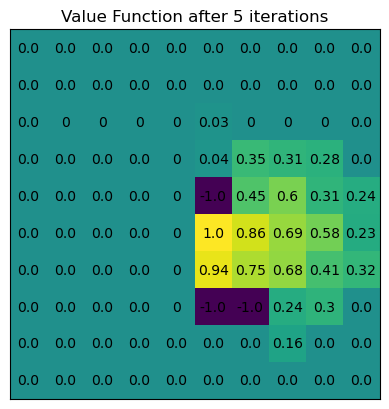

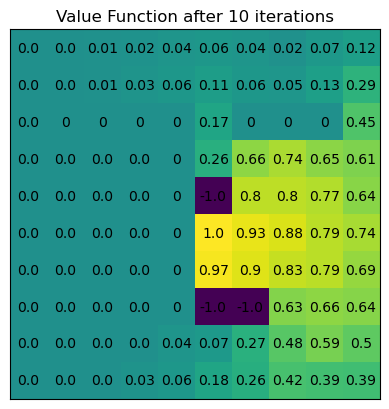

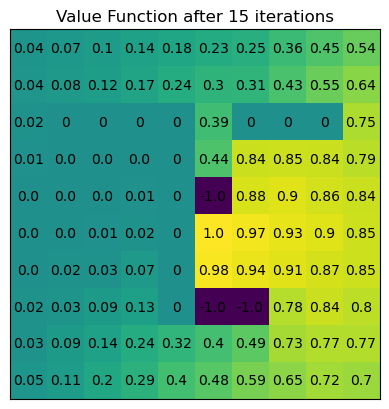

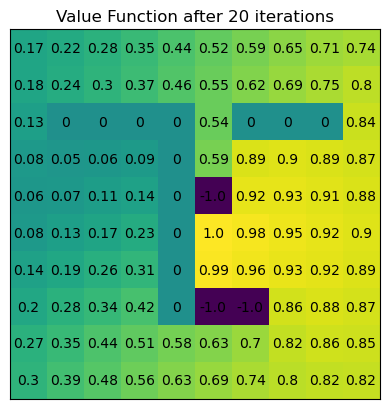

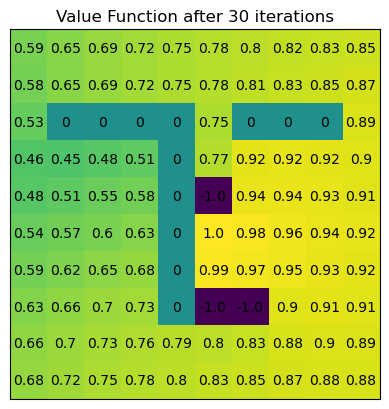

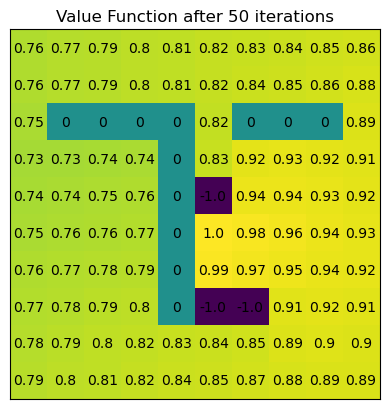

In [148]:

gridworld = EnvironmentNuevo(
[
['S',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ','#','#','#','#',' ','#','#','#',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1',' ',' ',' ',' '],
[' ',' ',' ',' ','#','+1',' ',' ',' ',' '],
[' ',' ',' ',' ','#',' ',' ',' ',' ',' '],
[' ',' ',' ',' ','#','-1','-1',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' '],
[' ',' ',' ',' ',' ',' ',' ',' ',' ',' ']
]
)
for i in [5, 10, 15, 20, 30, 50]:

    valit=ValueIteration(gridworld, iterations=i, gamma=0.99)
    # print(valit.values)
    valit.run_value_iteration()
    
    # print(f"Values after {i} iterations:")
    plot_value_function(valit.values, title=f"Value Function after {i} iterations")
    # for row in valit.values:
        # print(row)

In [150]:
bridge = EnvironmentNuevo([
    ['#', '-100','-100','-100','-100','-100','#'],
    ['+1',    0,     0,     0,     0,     0,  '+100'],
    ['#', '-100','-100','-100','-100','-100','#'],
])
for i in [0.9,0.8,0.7,0.6,0.5,0.4,0.3,0.2,0.1]:

    valit=ValueIteration(bridge, iterations=100, gamma=i)
    # print(valit.values)
    valit.run_value_iteration()
    
    print(f"Values with gamma {i} :")
    print(valit.values)
    # plot_value_function(valit.values, title=f"Value Function with gamma {i}")

Values with gamma 0.9 :
[[0, -100.0, -100.0, -100.0, -100.0, -100.0, 0], [1.0, -29.3, -48.459, -33.024, -4.800000000000001, 40.0, 100.0], [0, -100.0, -100.0, -100.0, -100.0, -100.0, 0]]
Values with gamma 0.8 :
[[0, -100.0, -100.0, -100.0, -100.0, -100.0, 0], [1.0, -29.3, -46.408, -34.256, -7.600000000000001, 40.0, 100.0], [0, -100.0, -100.0, -100.0, -100.0, -100.0, 0]]
Values with gamma 0.7 :
[[0, -100.0, -100.0, -100.0, -100.0, -100.0, 0], [1.0, -29.3, -44.357, -35.096000000000004, -10.400000000000002, 40.0, 100.0], [0, -100.0, -100.0, -100.0, -100.0, -100.0, 0]]
Values with gamma 0.6 :
[[0, -100.0, -100.0, -100.0, -100.0, -100.0, 0], [1.0, -29.3, -42.306, -35.544, -13.200000000000003, 40.0, 100.0], [0, -100.0, -100.0, -100.0, -100.0, -100.0, 0]]
Values with gamma 0.5 :
[[0, -100.0, -100.0, -100.0, -100.0, -100.0, 0], [1.0, -29.3, -40.254999999999995, -35.6, -16.0, 40.0, 100.0], [0, -100.0, -100.0, -100.0, -100.0, -100.0, 0]]
Values with gamma 0.4 :
[[0, -100.0, -100.0, -100.0, -100.0